In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import pickle
import os

print("✅ All imports successful")
print(f"XGBoost version: {xgb.__version__}")

✅ All imports successful
XGBoost version: 1.7.6


In [2]:
df = pd.read_csv('../data/upi_features.csv')

print(f"Shape: {df.shape}")
print(f"Failure rate: {df['is_failed'].mean()*100:.2f}%")
print(f"\nFeatures: {df.shape[1] - 1}")
df.head(3)

Shape: (500000, 34)
Failure rate: 29.27%

Features: 33


,sender_bank_encoded,receiver_bank_encoded,day_of_week,is_salary_day,is_festival_day,amount,sender_bank_health,receiver_bank_health,sender_recent_fail_rate,receiver_recent_fail_rate,...,network_type_4G,network_type_wifi,device_type_android,device_type_feature_phone,device_type_ios,amount_bucket_large,amount_bucket_medium,amount_bucket_micro,amount_bucket_small,amount_bucket_very_large
0,1,1,0,0,0,1207.20,0.93,0.88,0.02,0.05,...,False,False,True,False,False,False,True,False,False,False
1,1,6,6,0,0,1275.47,0.95,0.79,0.02,0.19,...,True,False,True,False,False,False,True,False,False,False
2,3,6,6,0,0,1362.76,0.64,0.64,0.04,0.11,...,True,False,True,False,False,False,True,False,False,False


In [3]:
X = df.drop(columns=['is_failed'])
y = df['is_failed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # important — preserves 10% failure ratio in both splits
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"\nTrain failure rate: {y_train.mean()*100:.2f}%")
print(f"Test failure rate:  {y_test.mean()*100:.2f}%")

Train size: (400000, 33)
Test size:  (100000, 33)

Train failure rate: 29.27%
Test failure rate:  29.27%


In [4]:
# Check where NaNs are
print("NaN count per column:")
nan_cols = X_train.isnull().sum()
print(nan_cols[nan_cols > 0])
print(f"\nTotal NaN values: {X_train.isnull().sum().sum()}")

# Fix 1: Fill numerical NaNs with median
num_cols = X_train.select_dtypes(include=[np.number]).columns
X_train[num_cols] = X_train[num_cols].fillna(X_train[num_cols].median())
X_test[num_cols] = X_test[num_cols].fillna(X_train[num_cols].median())  # use train median for test

# Fix 2: Fill boolean/dummy NaNs with 0
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Verify
print(f"\nAfter fix — NaN in X_train: {X_train.isnull().sum().sum()}")
print(f"After fix — NaN in X_test:  {X_test.isnull().sum().sum()}")
print("✅ NaN fix complete, safe to run SMOTE now")

NaN count per column:
network_risk         71923
sender_risk_score    71923
dtype: int64

Total NaN values: 143846

After fix — NaN in X_train: 0
After fix — NaN in X_test:  0
✅ NaN fix complete, safe to run SMOTE now


In [5]:
print(f"Before SMOTE — Class 0: {(y_train==0).sum()}, Class 1: {(y_train==1).sum()}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"After SMOTE  — Class 0: {(y_train_sm==0).sum()}, Class 1: {(y_train_sm==1).sum()}")
print(f"\nTraining set size after SMOTE: {X_train_sm.shape}")
print(f"Failure rate after SMOTE: {y_train_sm.mean()*100:.2f}%")

Before SMOTE — Class 0: 282920, Class 1: 117080
After SMOTE  — Class 0: 282920, Class 1: 282920

Training set size after SMOTE: (565840, 33)
Failure rate after SMOTE: 50.00%


In [6]:
baseline_model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
    # removed scale_pos_weight — SMOTE already balanced the data
)

baseline_model.fit(X_train_sm, y_train_sm)
y_prob_base = baseline_model.predict_proba(X_test)[:, 1]
y_pred_base = (y_prob_base >= 0.3).astype(int)

print("=== BASELINE MODEL ===")
print(classification_report(y_test, y_pred_base, target_names=['Success', 'Failure']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_base):.4f}")

=== BASELINE MODEL ===
              precision    recall  f1-score   support

     Success       0.79      0.60      0.68     70730
     Failure       0.39      0.61      0.47     29270

    accuracy                           0.60    100000
   macro avg       0.59      0.60      0.58    100000
weighted avg       0.67      0.60      0.62    100000

AUC-ROC: 0.6482


In [7]:
tuned_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    base_score=0.5,        # ← explicit float, fixes SHAP bug
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

tuned_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_prob_tuned = tuned_model.predict_proba(X_test)[:, 1]
y_pred_tuned = (y_prob_tuned >= 0.3).astype(int)

print("=== TUNED MODEL ===")
print(classification_report(y_test, y_pred_tuned, target_names=['Success', 'Failure']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_tuned):.4f}")

=== TUNED MODEL ===
              precision    recall  f1-score   support

     Success       0.80      0.53      0.64     70730
     Failure       0.37      0.67      0.48     29270

    accuracy                           0.57    100000
   macro avg       0.59      0.60      0.56    100000
weighted avg       0.67      0.57      0.59    100000

AUC-ROC: 0.6482


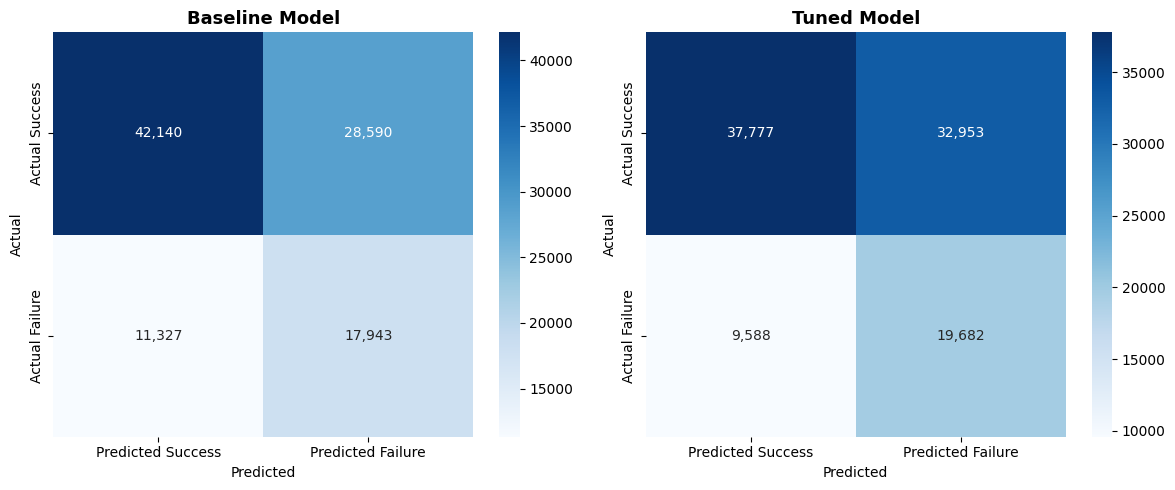

✅ Saved: 10_confusion_matrix.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, title in zip(axes,
                            [y_pred_base, y_pred_tuned],
                            ['Baseline Model', 'Tuned Model']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
                xticklabels=['Predicted Success', 'Predicted Failure'],
                yticklabels=['Actual Success', 'Actual Failure'])
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../notebooks/plots/10_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 10_confusion_matrix.png")

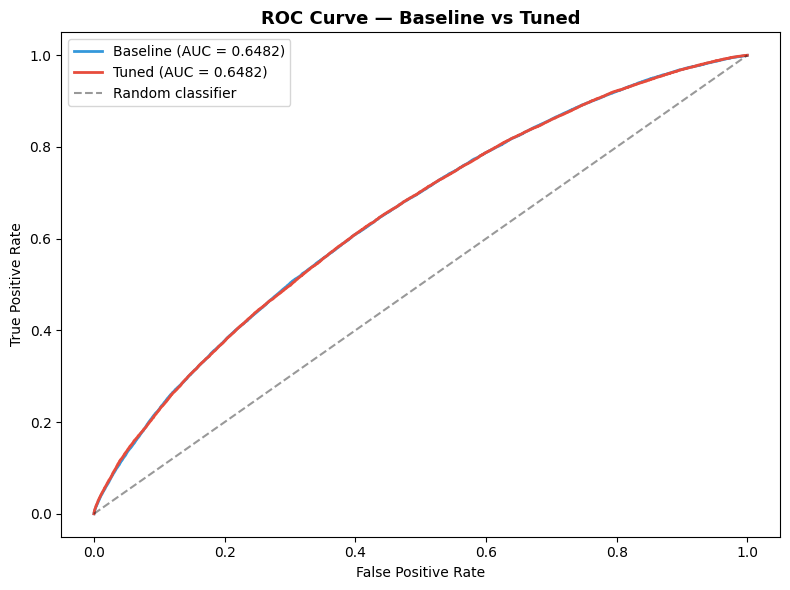

✅ Saved: 11_roc_curve.png


In [9]:
plt.figure(figsize=(8, 6))

for prob, label, color in zip(
    [y_prob_base, y_prob_tuned],
    ['Baseline', 'Tuned'],
    ['#3498db', '#e74c3c']
):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{label} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Baseline vs Tuned', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/plots/11_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 11_roc_curve.png")

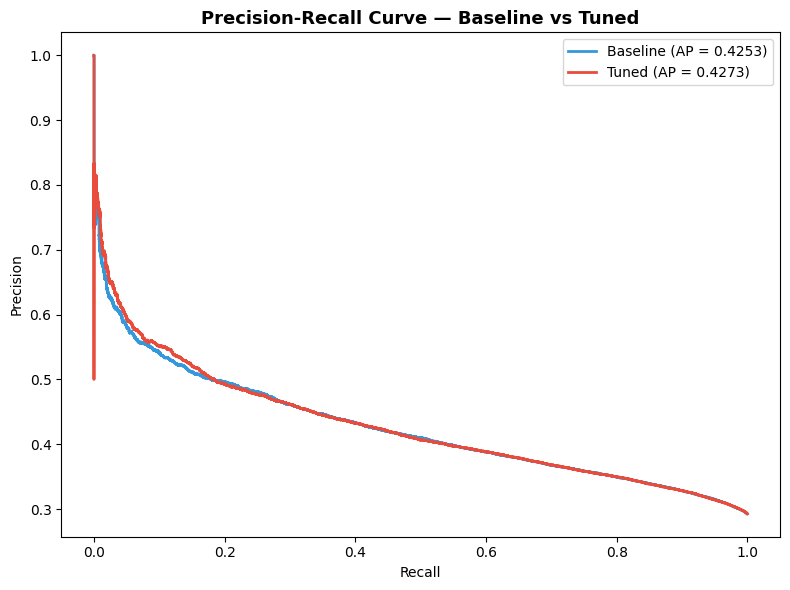

✅ Saved: 12_precision_recall_curve.png


In [10]:
plt.figure(figsize=(8, 6))

for prob, label, color in zip(
    [y_prob_base, y_prob_tuned],
    ['Baseline', 'Tuned'],
    ['#3498db', '#e74c3c']
):
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(recall, precision, color=color, linewidth=2, label=f'{label} (AP = {ap:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Baseline vs Tuned', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/plots/12_precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 12_precision_recall_curve.png")

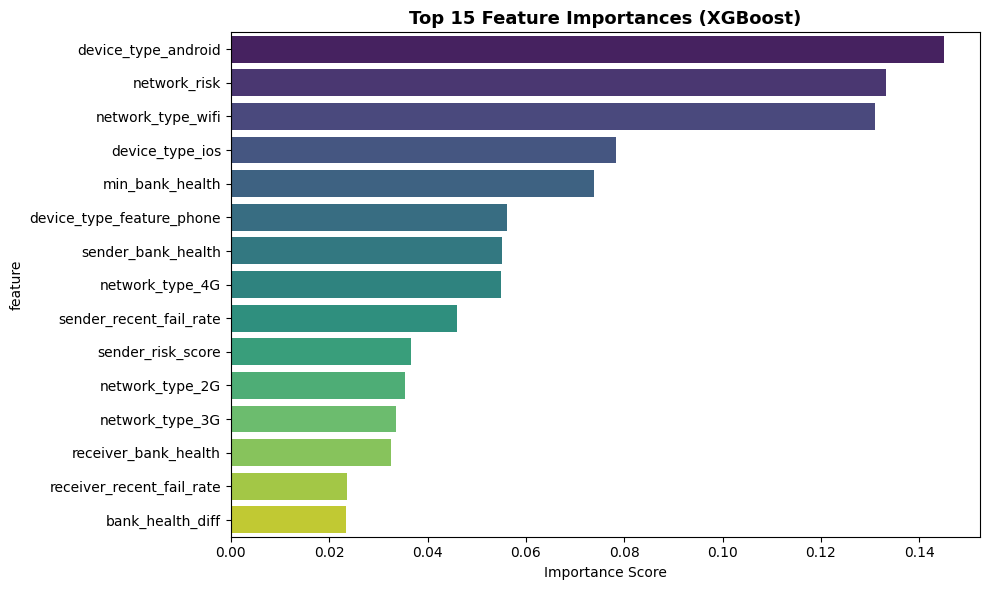

✅ Saved: 13_feature_importance.png


In [11]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': tuned_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances (XGBoost)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../notebooks/plots/13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 13_feature_importance.png")

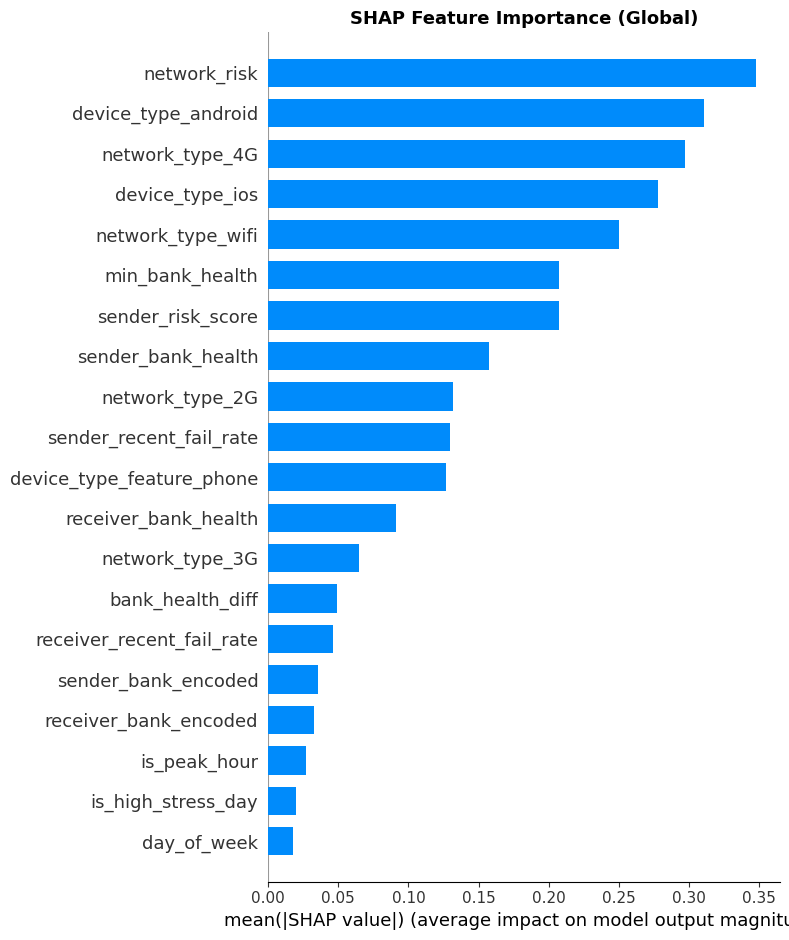

✅ Saved: 14_shap_summary_bar.png


In [12]:
X_sample = X_test.sample(5000, random_state=42).astype(np.float32)

explainer = shap.TreeExplainer(tuned_model)
shap_values = explainer.shap_values(X_sample)

plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Global)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/plots/14_shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 14_shap_summary_bar.png")

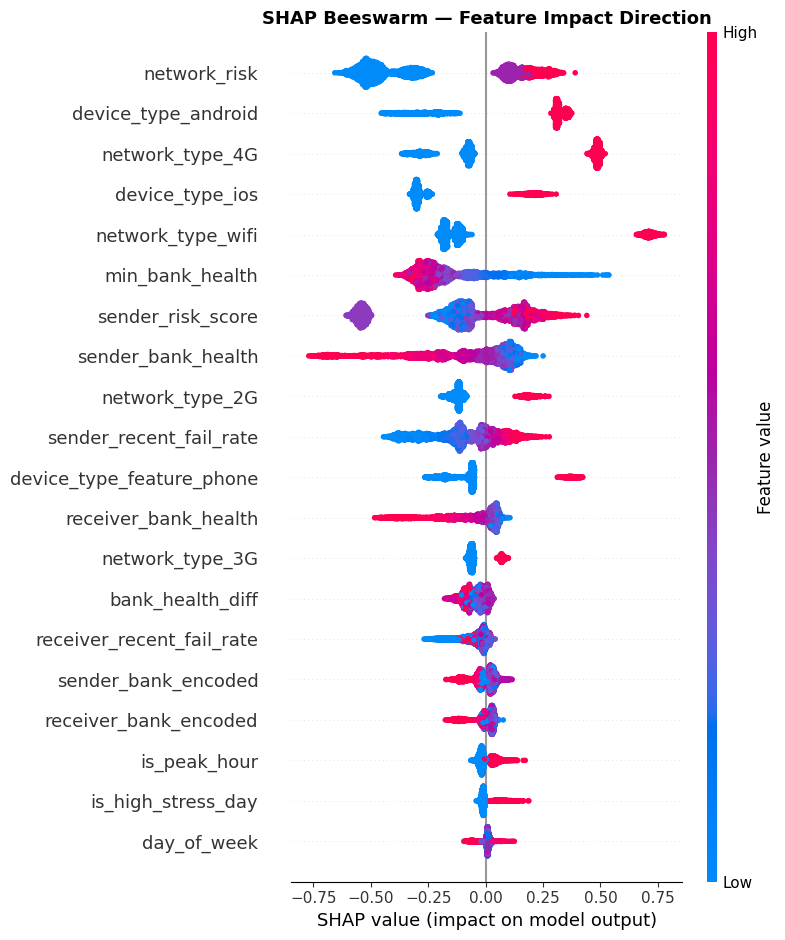

✅ Saved: 15_shap_beeswarm.png


In [13]:
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/plots/15_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 15_shap_beeswarm.png")

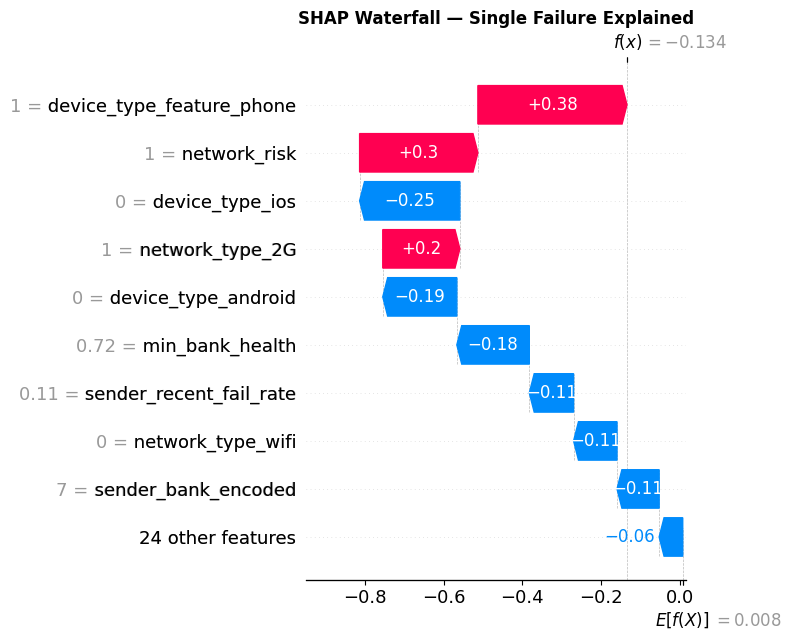

✅ Saved: 16_shap_waterfall.png


In [14]:
failed_sample = X_test[y_test == 1].iloc[0:1].astype(np.float32)  # fix dtype here too
shap_single = explainer(failed_sample)

plt.figure()
shap.plots.waterfall(shap_single[0], show=False)
plt.title('SHAP Waterfall — Single Failure Explained', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/plots/16_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 16_shap_waterfall.png")

In [15]:
os.makedirs('../models', exist_ok=True)

with open('../models/xgb_model.pkl', 'wb') as f:
    pickle.dump(tuned_model, f)

# Save feature names too — needed by FastAPI later
feature_names = list(X_train.columns)
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("✅ Saved: ../models/xgb_model.pkl")
print("✅ Saved: ../models/feature_names.pkl")
print(f"\nModel trained on {X_train_sm.shape[0]:,} samples (after SMOTE)")
print(f"Test AUC-ROC: {roc_auc_score(y_test, y_prob_tuned):.4f}")
print("\n🎯 Day 4 Complete! Ready for Week 2: FastAPI + Redis")

✅ Saved: ../models/xgb_model.pkl
✅ Saved: ../models/feature_names.pkl

Model trained on 565,840 samples (after SMOTE)
Test AUC-ROC: 0.6482

🎯 Day 4 Complete! Ready for Week 2: FastAPI + Redis
